In [ ]:
!pip install cartopy
!pip install geopandas
!pip install folium
!pip install geodatasets

In [3]:
from google.colab import drive
# Manipulação e análise de dados
import pandas as pd
import numpy as np
# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
# Manipulação de textos
import textwrap
# Análise geoespacial
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# Funções matemáticas
import math

In [4]:


# Monta o Google Drive
drive.mount('/content/drive')

df = pd.read_csv(
    "/content/drive/MyDrive/Curso_Data_Science/3_semana/datatran2026.csv",
    sep=";",
    encoding="latin1",
    decimal=","
)

Mounted at /content/drive


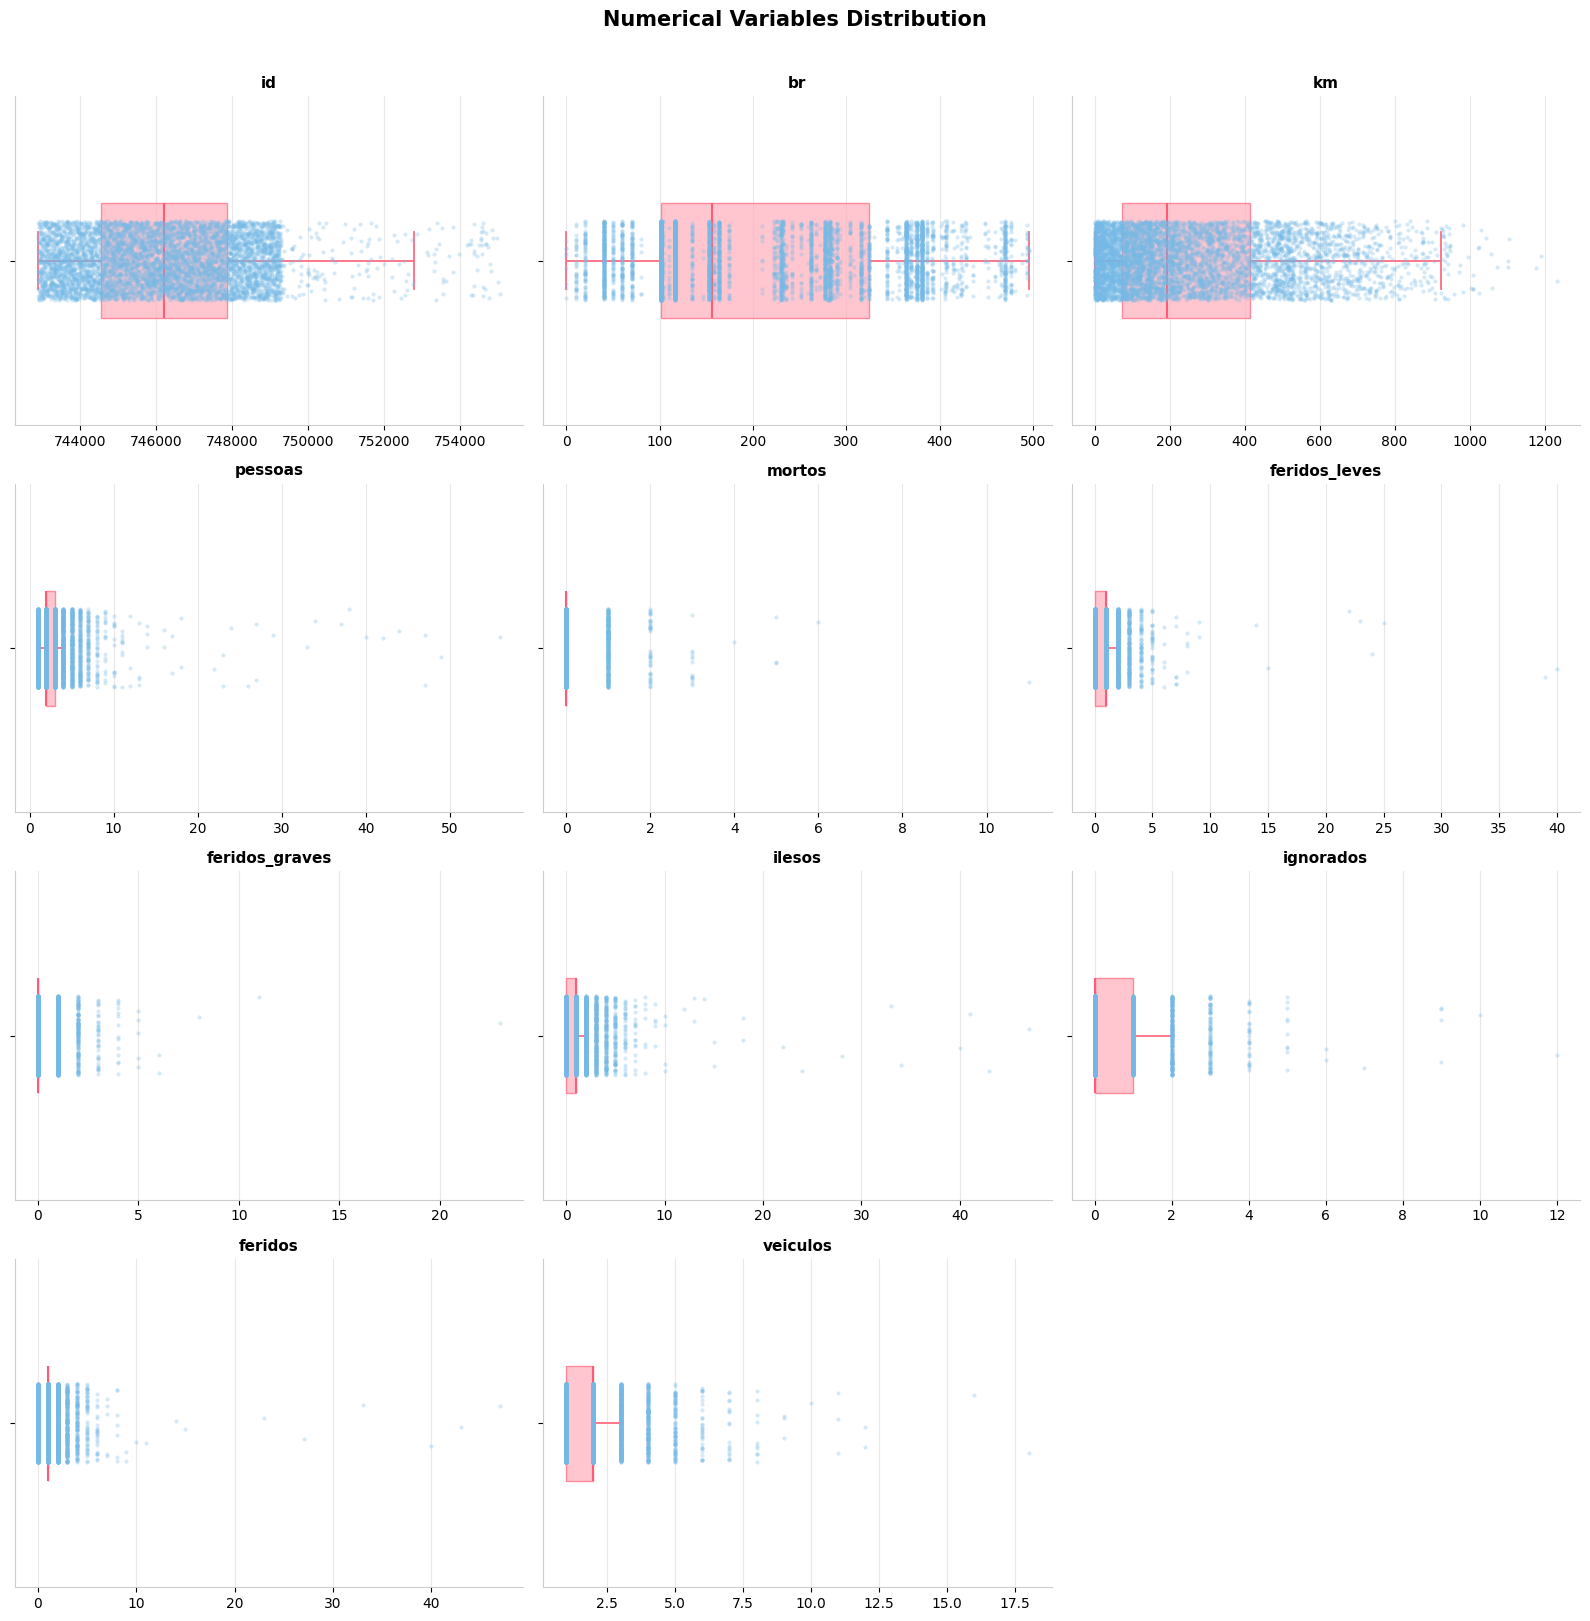

In [18]:
# Boxplots of numerical variables
# Selects numerical variables and removes latitude and longitude
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
colunas_numericas = (
    df.select_dtypes(include="number")
      .columns
      .drop(["latitude", "longitude"], errors="ignore")
)

ncols = 3
nrows = math.ceil(len(colunas_numericas) / ncols)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 4 * nrows)
)

axes = axes.flatten()
for ax, col in zip(axes, colunas_numericas):


    # Pink boxplot
    sns.boxplot(
        x=df[col],
        ax=ax,
        width=0.35,
        showfliers=False,
        boxprops={
            "facecolor": "#FFB3C1",
            "edgecolor": "#FF6B81",
            "alpha": 0.75
        },
        whiskerprops={
            "color": "#FF6B81",
            "linewidth": 1.3
        },
        capprops={
            "color": "#FF6B81",
            "linewidth": 1.3
        },
        medianprops={
            "color": "#FF5A76",
            "linewidth": 1.5
        }
    )
    # Individual data points in blue
    sns.stripplot(
        x=df[col],
        ax=ax,
        color="#75B9E6",
        alpha=0.30,
        size=3,
        jitter=0.12
    )
    # Plot styling
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_facecolor("white")
    ax.grid(
        axis="x",
        color="#D9D9D9",
        linewidth=0.8,
        alpha=0.6
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
# Removes unused axes
for ax in axes[len(colunas_numericas):]:
    fig.delaxes(ax)

fig.suptitle(
    "Numerical Variables Distribution",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

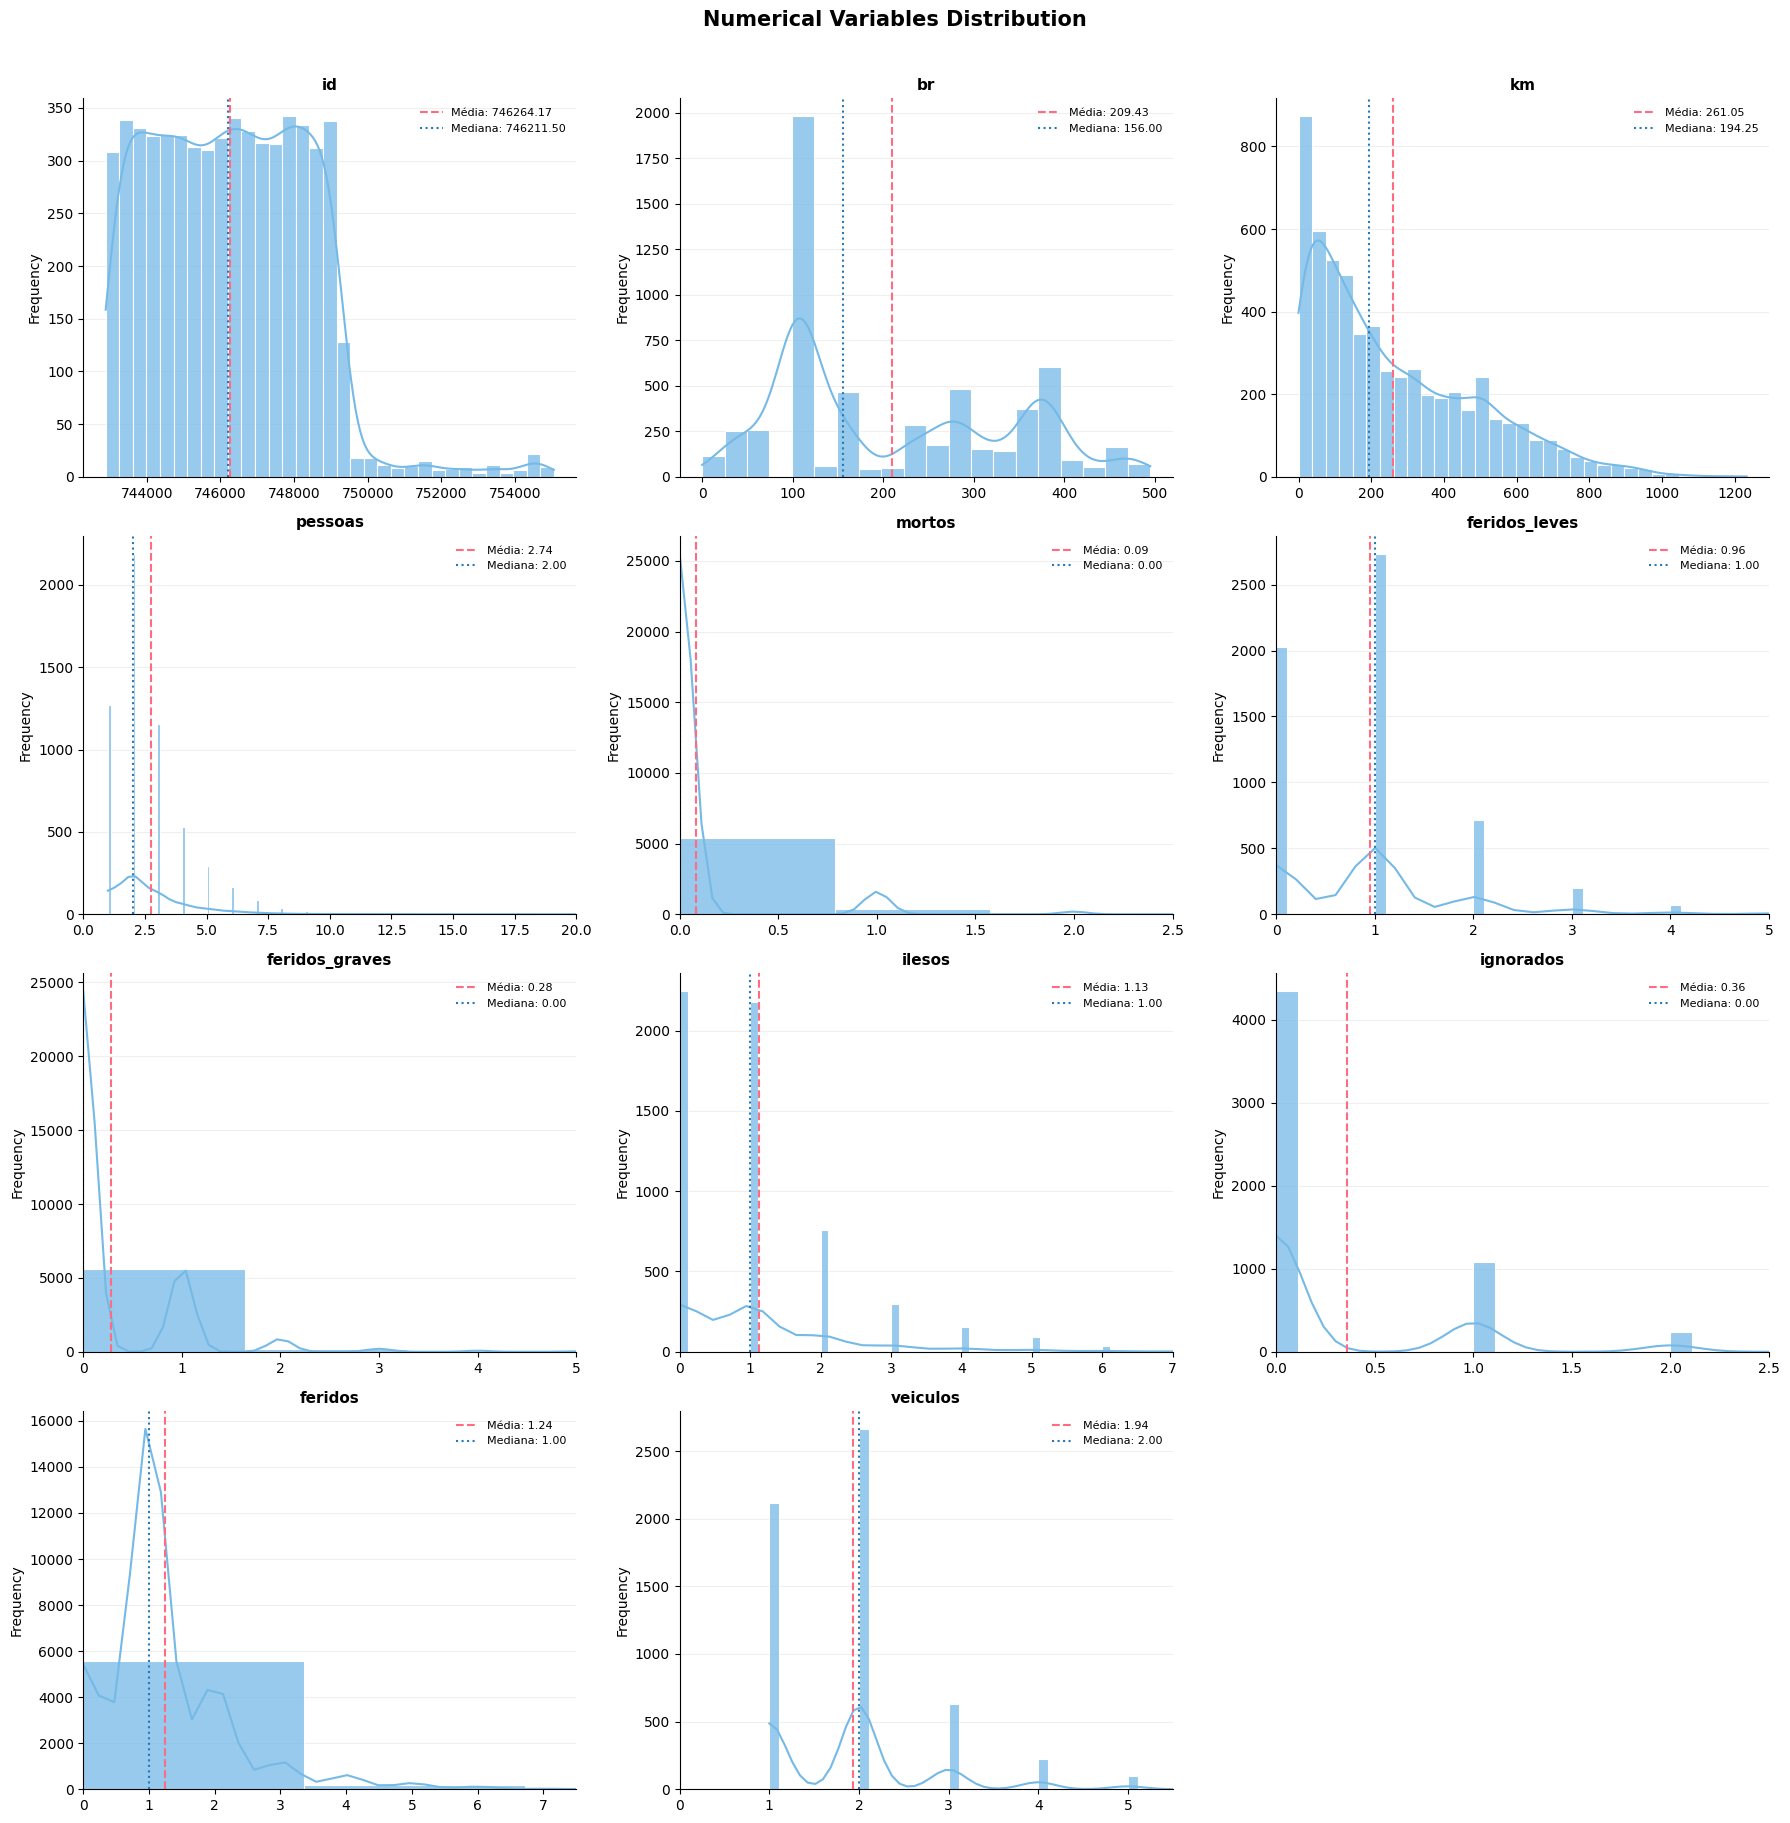

In [27]:
# Histogramas das variáveis numéricas
# Histograms of numerical variables

ncols = 3
nrows = math.ceil(len(colunas_numericas) / ncols)

# ============================================================
# DEFINA AQUI OS LIMITES DO EIXO X PARA VARIÁVEIS ESPECÍFICAS
# DEFINE HERE THE X-AXIS LIMITS FOR SPECIFIC VARIABLES
# ============================================================

limites_x = {
    "pessoas": (0, 20),
    "mortos": (0, 5),
    "feridos": (0, 7.5),
    "ilesos": (0, 7),
    "veiculos": (0, 5.5),
    "ignorados": (0, 2.5),
    "mortos": (0, 2.5),
    "feridos_graves": (0, 5),
    "feridos_leves": (0, 5),
    # "outra_coluna": (valor_minimo, valor_maximo),
}

# ============================================================

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 4.5 * nrows)
)

axes = axes.flatten()

for ax, col in zip(axes, colunas_numericas):

    dados = df[col].dropna()


    # Histogram with density curve
    sns.histplot(
        dados,
        bins="auto",
        kde=True,
        color="#75B9E6",
        edgecolor="white",
        linewidth=0.8,
        alpha=0.75,
        ax=ax
    )


    # Mean and median
    media = dados.mean()
    mediana = dados.median()

    ax.axvline(
        media,
        color="#FF6B81",
        linestyle="--",
        linewidth=1.5,
        label=f"Média: {media:.2f}"
    )

    ax.axvline(
        mediana,
        color="#2878B5",
        linestyle=":",
        linewidth=1.5,
        label=f"Mediana: {mediana:.2f}"
    )

    # ========================================================

    # APPLIES X-AXIS LIMITS ONLY TO SELECTED COLUMNS
    # ========================================================
    if col in limites_x:
        ax.set_xlim(limites_x[col])
    # ========================================================


    # Styling
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

    ax.grid(
        axis="y",
        alpha=0.2,
        linewidth=0.8
    )

    ax.set_axisbelow(True)
    ax.legend(frameon=False, fontsize=8)

    sns.despine(ax=ax)

# Removes unused axes
for ax in axes[len(colunas_numericas):]:
    fig.delaxes(ax)

fig.suptitle(
    "Numerical Variables Distribution",
    fontsize=15,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

In [28]:
# Acidentes por mês
# Accidents by month

import matplotlib.dates as mdates

# Garante que a variável esteja no formato de data
# Ensures the variable is in datetime format
df["data_inversa"] = pd.to_datetime(
    df["data_inversa"],
    dayfirst=True,
    errors="coerce"
)

# Agrupa os acidentes por mês
# Groups accidents by month
acidentes_por_mes = (
    df.dropna(subset=["data_inversa"])
      .set_index("data_inversa")
      .resample("MS")
      .size()
      .rename("qtd_acidentes")
      .reset_index()
)

# Média móvel de 3 meses para visualizar a tendência
# 3-month moving average to visualize the trend
acidentes_por_mes["media_movel_3m"] = (
    acidentes_por_mes["qtd_acidentes"]
    .rolling(window=3, center=True)
    .mean()
)

# Exibe os dados
display(acidentes_por_mes)

,data_inversa,qtd_acidentes,media_movel_3m
0,2026-01-01,195,NaN
1,2026-02-01,185,194.333333
2,2026-03-01,203,199.333333
3,2026-04-01,210,199.666667
4,2026-05-01,186,182.333333
5,2026-06-01,151,170.333333
6,2026-07-01,174,164.666667
7,2026-08-01,169,171.666667
8,2026-09-01,172,186.333333
9,2026-10-01,218,198.666667


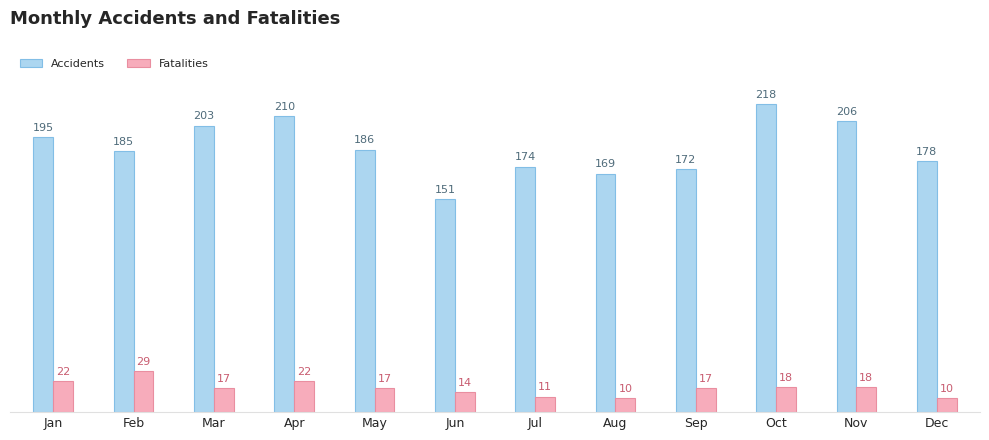

In [60]:
# =========================================================
# Acidentes e vítimas fatais por mês
# Accidents and fatalities by month
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")

fig, ax = plt.subplots(figsize=(10, 4.5))

# =========================================================
# Posição das barras
# Bar positions
# =========================================================

x = np.arange(len(resumo_mensal)) * 0.65

# Barras finas
largura = 0.16

# =========================================================
# Acidentes - azul pastel
# Accidents - pastel blue
# =========================================================

barras_acidentes = ax.bar(
    x - largura / 2,
    resumo_mensal["qtd_acidentes"],
    width=largura,
    color="#A8D4F0",
    edgecolor="#7EBCE6",
    linewidth=0.8,
    alpha=0.95,
    label="Accidents"
)

# =========================================================
# Vítimas fatais - vermelho pastel
# Fatalities - pastel red
# =========================================================

barras_mortos = ax.bar(
    x + largura / 2,
    resumo_mensal["qtd_mortos"],
    width=largura,
    color="#F7A8B8",
    edgecolor="#E98A9D",
    linewidth=0.8,
    alpha=0.95,
    label="Fatalities"
)

# =========================================================
# Valores sobre as barras
# Values above the bars
# =========================================================

ax.bar_label(
    barras_acidentes,
    fmt="%.0f",
    padding=3,
    fontsize=8,
    color="#4F6B7A"
)

ax.bar_label(
    barras_mortos,
    fmt="%.0f",
    padding=3,
    fontsize=8,
    color="#C85C70"
)

# =========================================================
# Meses
# Months
# =========================================================

meses = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

ax.set_xticks(x)
ax.set_xticklabels(
    meses[:len(resumo_mensal)],
    fontsize=9
)

# =========================================================
# Remove o eixo Y
# Removes the Y-axis
# =========================================================

ax.set_ylabel("")
ax.set_yticks([])

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Sem grade
ax.grid(False)

# Linha inferior discreta
ax.spines["bottom"].set_color("#E0E0E0")

# Remove pequenas marcas dos meses
ax.tick_params(axis="x", length=0)

# =========================================================
# Título
# Title
# =========================================================

ax.set_title(
    "Monthly Accidents and Fatalities",
    fontsize=13,
    fontweight="bold",
    loc="left",
    pad=18
)

# Legenda
ax.legend(
    frameon=False,
    fontsize=8,
    loc="upper left",
    ncol=2
)

# Espaço para os valores acima das barras
ax.set_ylim(
    0,
    resumo_mensal["qtd_acidentes"].max() * 1.18
)

# Ajusta as laterais
ax.set_xlim(
    x[0] - 0.35,
    x[-1] + 0.35
)

plt.tight_layout()
plt.show()

In [63]:

# =========================
# 2. Contar acidentes únicos
# =========================
df_plot = df.drop_duplicates(subset="id").copy()


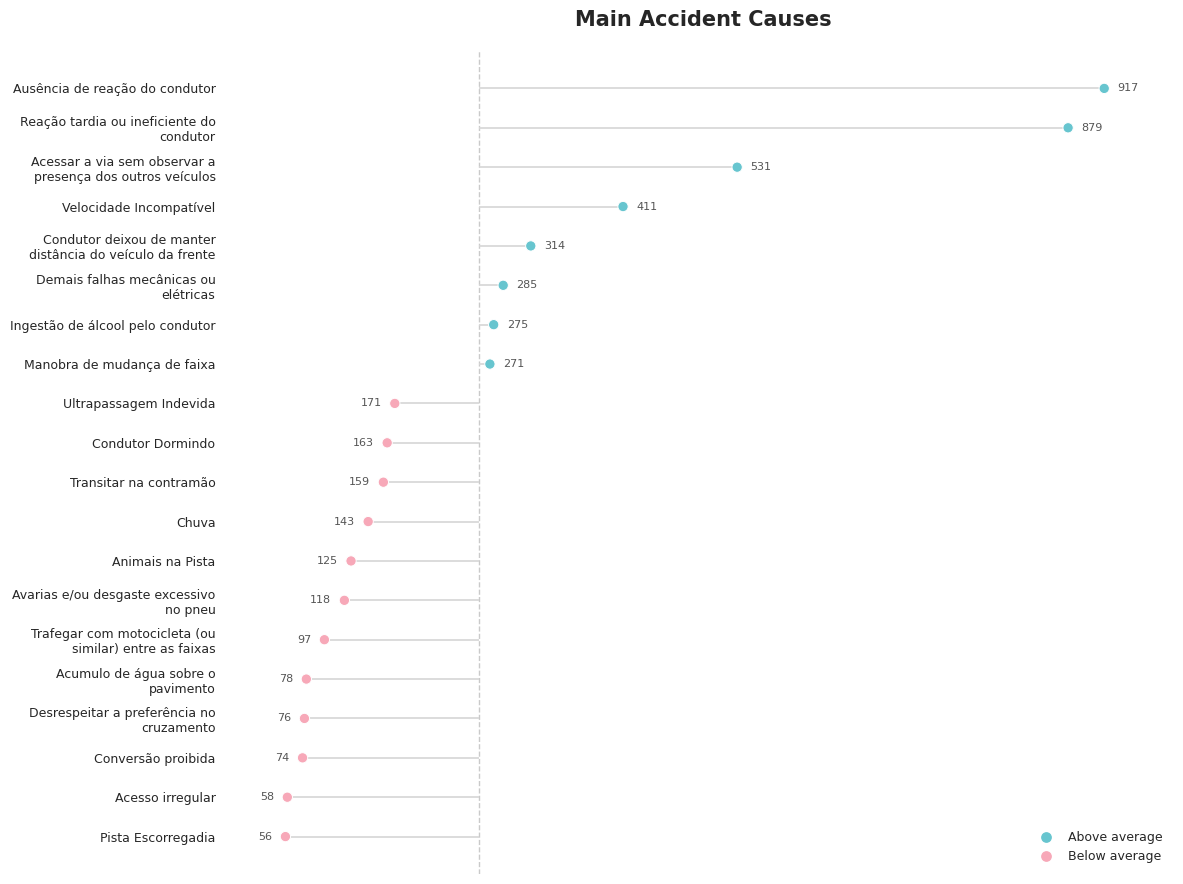

In [73]:
# =========================================================
# Frequência das principais causas de acidentes
# Accident causes frequency
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

top_n = 20

# =========================================================
# Preparação dos dados
# Data preparation
# =========================================================

causas = (
    df["causa_acidente"]
    .dropna()
    .value_counts()
    .head(top_n)
    .sort_values()
    .reset_index()
)

causas.columns = ["causa_acidente", "quantidade"]

media = causas["quantidade"].mean()

causas["causa_formatada"] = causas["causa_acidente"].apply(
    lambda x: "\n".join(textwrap.wrap(str(x), width=32))
)

cores = np.where(
    causas["quantidade"] >= media,
    "#67C5CF",
    "#F7A8B8"
)

# =========================================================
# Gráfico
# Plot
# =========================================================

fig, ax = plt.subplots(figsize=(12, 9))

y = np.arange(len(causas))

# Linhas entre os pontos e a média
# Lines between points and the average
for i, valor in enumerate(causas["quantidade"]):
    ax.hlines(
        y=i,
        xmin=min(media, valor),
        xmax=max(media, valor),
        color="#D6D6D6",
        linewidth=1.2,
        zorder=1
    )

# Pontos
# Dots
ax.scatter(
    causas["quantidade"],
    y,
    c=cores,
    s=55,
    edgecolor="white",
    linewidth=0.7,
    zorder=3
)

# Linha vertical da média
# Average vertical line
ax.axvline(
    media,
    color="#BDBDBD",
    linestyle="--",
    linewidth=1,
    alpha=0.8,
    zorder=0
)

# =========================================================
# Valores ao lado dos pontos
# Values next to the dots
# =========================================================

offset = causas["quantidade"].max() * 0.015

for i, valor in enumerate(causas["quantidade"]):

    if valor >= media:
        # Acima da média: valor à direita do ponto
        # Above average: value to the right of the dot
        ax.text(
            valor + offset,
            i,
            f"{valor:,}",
            va="center",
            ha="left",
            fontsize=8,
            color="#555555"
        )

    else:
        # Abaixo da média: valor à esquerda do ponto
        # Below average: value to the left of the dot
        ax.text(
            valor - offset,
            i,
            f"{valor:,}",
            va="center",
            ha="right",
            fontsize=8,
            color="#555555"
        )

# =========================================================
# Eixo Y
# Y-axis
# =========================================================

ax.set_yticks(y)

ax.set_yticklabels(
    causas["causa_formatada"],
    fontsize=9
)

# Afasta os nomes das causas da área do gráfico
# Moves category labels away from the plot area
ax.tick_params(
    axis="y",
    pad=12,
    length=0
)

# =========================================================
# Remove o eixo X
# Removes the X-axis
# =========================================================

ax.set_xlabel("")
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

# Dá espaço para os valores nas extremidades
# Adds space for values at the edges
ax.set_xlim(
    0,
    causas["quantidade"].max() * 1.08
)

# =========================================================
# Título
# Title
# =========================================================

ax.set_title(
    "Main Accident Causes",
    fontsize=15,
    fontweight="bold",
    pad=18
)

# =========================================================
# Estética
# Styling
# =========================================================

ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# =========================================================
# Legenda
# Legend
# =========================================================

ax.scatter(
    [],
    [],
    color="#67C5CF",
    s=45,
    label="Above average"
)

ax.scatter(
    [],
    [],
    color="#F7A8B8",
    s=45,
    label="Below average"
)

ax.legend(
    frameon=False,
    fontsize=9,
    loc="lower right"
)

# Espaço para os nomes longos das causas
# Space for long cause labels
plt.subplots_adjust(left=0.32)

plt.tight_layout()
plt.show()